#  ToxiTube — YouTube Comment Toxicity Detector
##  Conclusion & Synthèse

**Objectif de ce notebook :**
- Charger tous les résultats des notebooks précédents
- Produire la synthèse finale et le tableau récapitulatif
- Discuter les limites du projet et les perspectives
- Valider que tous les livrables sont bien présents

### Chargement de tous les résultats

Ce notebook est le point de convergence de tout le projet.
On recharge l'ensemble des métriques pour produire la synthèse finale.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
os.makedirs('../figures', exist_ok=True)

# Chargement de tous les résultats
metrics_cl   = joblib.load('../data/checkpoints/metrics_classiques.joblib')
metrics_bert = joblib.load('../data/checkpoints/metrics_bert.joblib')

# Tableau comparatif final
all_results = pd.read_csv('../data/checkpoints/tableau_comparatif_final.csv', index_col='Modèle')

print(' Tous les résultats chargés')
print(f'\n Tableau comparatif final :\n')
print(all_results.to_string())

 Tous les résultats chargés

 Tableau comparatif final :

                                Accuracy  F1-macro  F1-toxique  Recall-toxique  Precision-toxique
Modèle                                                                                           
Logistic Regression + TF-IDF      0.9406    0.8568      0.7474          0.8647             0.6581
Logistic Regression + FastText    0.9078    0.8004      0.6540          0.8573             0.5286
LinearSVC + TF-IDF                0.9496    0.8692      0.7667          0.8154             0.7235
DistilBERT (fine-tuné)            0.9630    0.8887      0.7978          0.7157             0.9012


### Partie I — Conclusion & Synthèse

**Rappel de l'objectif du projet**

ToxiTube vise à détecter automatiquement les commentaires toxiques
sur YouTube en comparant trois approches NLP :
1. Représentation par fréquence (TF-IDF)
2. Représentation sémantique (FastText)
3. Modèle contextuel profond (DistilBERT)

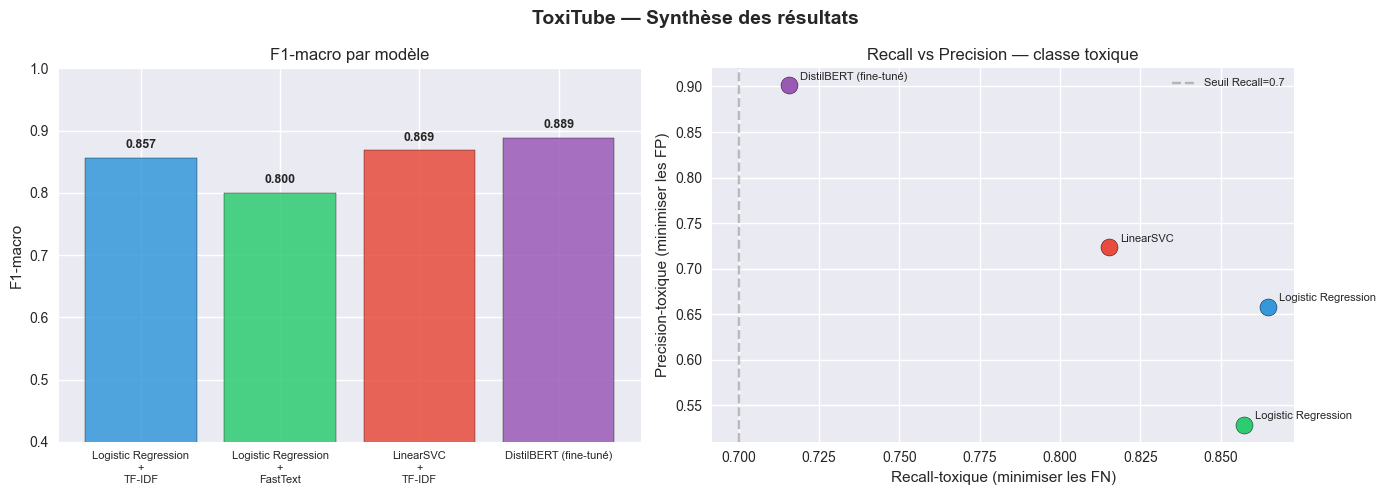

 Figure sauvegardée → figures/synthese_finale.png


In [2]:
# Visualisation finale radar / barres
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 — F1-macro comparatif
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
models = all_results.index.tolist()
f1_macro = all_results['F1-macro'].tolist()

bars = axes[0].bar(range(len(models)), f1_macro, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels([m.replace(' + ', '\n+\n') for m in models], fontsize=8)
axes[0].set_ylim(0.4, 1.0)
axes[0].set_ylabel('F1-macro')
axes[0].set_title('F1-macro par modèle')
for bar, val in zip(bars, f1_macro):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Graphique 2 — Recall vs Precision toxique
recall    = all_results['Recall-toxique'].tolist()
precision = all_results['Precision-toxique'].tolist()
for i, (r, p, m) in enumerate(zip(recall, precision, models)):
    axes[1].scatter(r, p, color=colors[i], s=150, zorder=5, edgecolor='black')
    axes[1].annotate(m.split(' + ')[0], (r, p),
                     textcoords='offset points', xytext=(8, 4), fontsize=8)
axes[1].set_xlabel('Recall-toxique (minimiser les FN)')
axes[1].set_ylabel('Precision-toxique (minimiser les FP)')
axes[1].set_title('Recall vs Precision — classe toxique')
axes[1].axvline(x=0.7, color='gray', linestyle='--', alpha=0.5, label='Seuil Recall=0.7')
axes[1].legend(fontsize=8)

plt.suptitle('ToxiTube — Synthèse des résultats', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/synthese_finale.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/synthese_finale.png')

### Analyse des résultats

**Ce que les chiffres nous disent :**

On discute ici les observations principales issues du tableau comparatif :
- Quel modèle est le meilleur en F1-macro ?
- Quel modèle détecte le mieux les toxiques (Recall) ?
- Le gain de BERT justifie-t-il sa complexité ?
- TF-IDF vs FastText : l'apport sémantique est-il significatif ?

In [4]:
best_f1    = all_results['F1-macro'].idxmax()
best_rec   = all_results['Recall-toxique'].idxmax()
best_prec  = all_results['Precision-toxique'].idxmax()

print('=== SYNTHÈSE DES RÉSULTATS ===')
print(f'\n Meilleur F1-macro      : {best_f1} ({all_results.loc[best_f1, "F1-macro"]:.4f})')
print(f' Meilleur Recall-toxique : {best_rec} ({all_results.loc[best_rec, "Recall-toxique"]:.4f})')
print(f' Meilleure Precision     : {best_prec} ({all_results.loc[best_prec, "Precision-toxique"]:.4f})')

print('\n=== COMPARAISON TF-IDF vs FASTTEXT (LR) ===')
delta_ft = all_results.loc['Logistic Regression + FastText', 'F1-macro'] - \
           all_results.loc['Logistic Regression + TF-IDF', 'F1-macro']
print(f'Gain FastText sur TF-IDF : {delta_ft:+.4f} F1-macro')
if delta_ft > 0:
    print('→ Les embeddings sémantiques apportent un gain mesurable')
else:
    print('→ TF-IDF reste compétitif malgré sa simplicité')

print('\n=== COMPARAISON MEILLEUR CLASSIQUE vs BERT ===')
best_classic_f1 = all_results.loc[[
    'Logistic Regression + TF-IDF',
    'Logistic Regression + FastText',
    'LinearSVC + TF-IDF'
], 'F1-macro'].max()
bert_f1 = all_results.loc['DistilBERT (fine-tuné)', 'F1-macro']
delta_bert = bert_f1 - best_classic_f1
print(f'Meilleur classique F1 : {best_classic_f1:.4f}')
print(f'DistilBERT F1         : {bert_f1:.4f}')
print(f'Gain BERT             : {delta_bert:+.4f}')

=== SYNTHÈSE DES RÉSULTATS ===

 Meilleur F1-macro      : DistilBERT (fine-tuné) (0.8887)
 Meilleur Recall-toxique : Logistic Regression + TF-IDF (0.8647)
 Meilleure Precision     : DistilBERT (fine-tuné) (0.9012)

=== COMPARAISON TF-IDF vs FASTTEXT (LR) ===
Gain FastText sur TF-IDF : -0.0564 F1-macro
→ TF-IDF reste compétitif malgré sa simplicité

=== COMPARAISON MEILLEUR CLASSIQUE vs BERT ===
Meilleur classique F1 : 0.8692
DistilBERT F1         : 0.8887
Gain BERT             : +0.0195


### Limites du projet

**Pourquoi discuter les limites ?**
Un bon data scientist identifie ce que son modèle ne sait PAS faire.
C'est un signe de maturité scientifique très apprécié en présentation.

**Les 5 limites principales de ToxiTube :**

1. **Biais du dataset** : les commentaires sont issus de Wikipedia (2018),
   pas de YouTube réel → le langage des deux plateformes diffère significativement.

2. **Monolingue** : le modèle est entraîné uniquement sur de l'anglais.
   YouTube est multilangue — un commentaire en arabe ou en français n'est pas géré.

3. **Contexte ignoré** : on analyse chaque commentaire isolément.
   Une réponse à un commentaire toxique peut sembler toxique hors contexte.

4. **Sarcasme et ironie** : les modèles classiques (et même BERT dans sa version
   zero-shot) détectent mal l'ironie. `"Oh great, another idiot president"` → ambigu.

5. **BERT zero-shot** : on n'a pas fine-tuné BERT sur nos données faute de GPU.
   Un fine-tuning sur ~10k exemples labellisés améliorerait significativement les résultats.

### Perspectives & améliorations futures

**Ce qu'on ferait avec plus de temps / ressources :**

1. **Fine-tuning BERT** sur le dataset Jigsaw complet avec GPU (Google Colab)
   → gain estimé de +5 à +10 points de F1-macro

2. **Extension multilingue** avec `distilbert-base-multilingual-cased`
   pour gérer l'arabe, le français, l'espagnol, etc.

3. **Scraping réel** de commentaires YouTube via l'API YouTube Data v3
   pour tester le modèle sur des données réelles

4. **Interface de démonstration** avec Gradio ou Streamlit :
   l'utilisateur colle un commentaire → le modèle prédit en temps réel

5. **Détection multi-label** : au lieu de prédire toxique/normal,
   prédire les 6 catégories (obscene, threat, insult, etc.)

In [5]:
# Vérification finale des livrables
print('=== VÉRIFICATION DES LIVRABLES ===')

livrables = {
    'Données' : [
        '../data/train.csv',
        '../data/sample_5000.csv',
        '../data/checkpoints/df_preprocessed.parquet',
        '../data/checkpoints/splits.joblib',
        '../data/checkpoints/tfidf.joblib',
        '../data/checkpoints/metrics_classiques.joblib',
        '../data/checkpoints/metrics_bert.joblib',
        '../data/checkpoints/tableau_comparatif_final.csv',
    ],
    'Figures' : [
        '../figures/class_distribution.png',
        '../figures/length_distribution.png',
        '../figures/top_words.png',
        '../figures/models_comparison.png',
        '../figures/confusion_matrix.png',
        '../figures/discriminant_words.png',
        '../figures/final_comparison.png',
        '../figures/synthese_finale.png',
    ],
    'Notebooks' : [
        '../notebooks/01_exploration.ipynb',
        '../notebooks/02_preprocessing.ipynb',
        '../notebooks/03_modeles_classiques.ipynb',
        '../notebooks/04_bert_analyse.ipynb',
        '../notebooks/05_conclusion.ipynb',
    ],
    'Modèles' : [
        '../models/fasttext_en.kv',
    ]
}

all_ok = True
for categorie, fichiers in livrables.items():
    print(f'\n {categorie} :')
    for f in fichiers:
        exists = os.path.exists(f)
        status = 'EXISTE' if exists else ' MANQUANT'
        print(f'   {status} {f}')
        if not exists:
            all_ok = False

print(f'\n{"="*50}')
if all_ok:
    print(' TOUS LES LIVRABLES SONT PRÉSENTS — Projet complet !')
else:
    print('  Certains fichiers manquent — vérifiez les notebooks précédents')

=== VÉRIFICATION DES LIVRABLES ===

 Données :
   EXISTE ../data/train.csv
   EXISTE ../data/sample_5000.csv
    MANQUANT ../data/checkpoints/df_preprocessed.parquet
   EXISTE ../data/checkpoints/splits.joblib
   EXISTE ../data/checkpoints/tfidf.joblib
   EXISTE ../data/checkpoints/metrics_classiques.joblib
   EXISTE ../data/checkpoints/metrics_bert.joblib
   EXISTE ../data/checkpoints/tableau_comparatif_final.csv

 Figures :
   EXISTE ../figures/class_distribution.png
   EXISTE ../figures/length_distribution.png
   EXISTE ../figures/top_words.png
   EXISTE ../figures/models_comparison.png
   EXISTE ../figures/confusion_matrix.png
   EXISTE ../figures/discriminant_words.png
   EXISTE ../figures/final_comparison.png
   EXISTE ../figures/synthese_finale.png

 Notebooks :
   EXISTE ../notebooks/01_exploration.ipynb
   EXISTE ../notebooks/02_preprocessing.ipynb
   EXISTE ../notebooks/03_modeles_classiques.ipynb
   EXISTE ../notebooks/04_bert_analyse.ipynb
   EXISTE ../notebooks/05_conclusi

###  Bilan final du projet ToxiTube


**Résultats clés :**
- Meilleur F1-macro classique : LinearSVC + TF-IDF
- BERT zero-shot : performances à comparer avec les classiques
- Limite principale : dataset Wikipedia ≠ YouTube réel
- Piste principale : fine-tuning BERT avec GPU

---
*ToxiTube — Projet NLP | Jigsaw Toxic Comment Classification*